In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from matplotlib import cm

In [2]:
# -----------------------------
# Configuration
# -----------------------------

IMG_SIZE = (224, 224)
CLASS_NAMES = ["real", "spoof"]


def find_project_root(start_path: Path | None = None) -> Path:
    current_path = start_path or Path.cwd()

    for path in [current_path, *current_path.parents]:
        if (path / ".gitignore").exists():
            return path

    raise FileNotFoundError("Could not find .gitignore. Check your notebook working directory.")


PROJECT_ROOT = find_project_root()

MODEL_PATH = (
    PROJECT_ROOT
    / "anti_spoofing_module_MobileNetV2"
    / "model"
    / "fasd_mobilenetv2_model.keras"
)

FACE_IMG_DIR = (
    PROJECT_ROOT
    / "Test_Face_Detect"
    / "Frame_IMGs"
)

print("Project root:", PROJECT_ROOT)
print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())
print("Face image folder:", FACE_IMG_DIR)
print("Face image folder exists:", FACE_IMG_DIR.exists())

Project root: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness
Model path: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\fasd_mobilenetv2_model.keras
Model exists: True
Face image folder: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\Test_Face_Detect\Frame_IMGs
Face image folder exists: True


In [3]:
def get_latest_face_image(face_img_dir: Path) -> Path:
    image_extensions = ["*.jpg", "*.jpeg", "*.png"]

    image_paths = []

    for extension in image_extensions:
        image_paths.extend(face_img_dir.glob(extension))

    image_paths = [path for path in image_paths if path.is_file()]

    if not image_paths:
        raise FileNotFoundError(f"No face images found in: {face_img_dir}")

    latest_image = max(image_paths, key=lambda path: path.stat().st_mtime)

    return latest_image


latest_face_image = get_latest_face_image(FACE_IMG_DIR)

print("Latest face image:", latest_face_image)
print("Latest face image exists:", latest_face_image.exists())

Latest face image: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\Test_Face_Detect\Frame_IMGs\frame_000225_20260515_153620_450682_face_1.jpg
Latest face image exists: True


In [4]:
anti_spoof_model = tf.keras.models.load_model(str(MODEL_PATH))

# Warm up model once
dummy_input = np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)
_ = anti_spoof_model(dummy_input, training=False)

print("Anti-spoofing model loaded and warmed up.")

Anti-spoofing model loaded and warmed up.


In [5]:
def build_gradcam_model(model, layer_name="anti_spoof_conv"):
    """
    Builds a Grad-CAM model that outputs:
    1. The selected convolutional layer output
    2. The final prediction output
    """

    gradcam_layer = model.get_layer(layer_name)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[gradcam_layer.output, model.output]
    )

    print("Using Grad-CAM layer:", gradcam_layer.name)
    print("Grad-CAM layer output shape:", gradcam_layer.output.shape)

    return grad_model


def make_gradcam_heatmap(input_batch, grad_model, class_index=None):
    """
    Creates Grad-CAM heatmap for one image.
    """

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(input_batch, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    gradients = tape.gradient(class_score, conv_output)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value.numpy() == 0:
        return heatmap.numpy(), predictions.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy(), predictions.numpy()


def create_gradcam_display_images(original_array, heatmap, alpha=0.4):
    """
    Creates:
    1. original image
    2. pure Grad-CAM heatmap
    3. Grad-CAM overlay
    """

    original_uint8 = original_array.astype("uint8")
    h, w = original_uint8.shape[:2]

    # Resize heatmap to image size using nearest neighbour to keep it pixelated
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=(h, w),
        method="nearest"
    ).numpy().squeeze()

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply jet colormap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    jet_heatmap_uint8 = np.uint8(jet_heatmap * 255)

    # Create overlay
    overlay_img = jet_heatmap_uint8 * alpha + original_uint8
    overlay_img = np.clip(overlay_img, 0, 255).astype("uint8")

    return original_uint8, jet_heatmap_uint8, overlay_img

In [6]:
def predict_real_or_spoof_with_gradcam(image_path: Path, model, grad_model, class_names):
    # Load image for model input
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    x = tf.keras.utils.img_to_array(img)
    input_batch = tf.expand_dims(x, axis=0)

    # Do not manually preprocess here because your saved model already includes preprocess_input
    heatmap, pred = make_gradcam_heatmap(
        input_batch=input_batch,
        grad_model=grad_model
    )

    if pred.shape[-1] == 1:
        score = float(pred[0][0])
        pred_idx = 1 if score >= 0.5 else 0
        confidence = score if pred_idx == 1 else 1 - score
    else:
        pred_idx = int(np.argmax(pred[0]))
        confidence = float(np.max(pred[0]))

    label = class_names[pred_idx]

    original_array = tf.keras.utils.img_to_array(img)

    original_img, gradcam_img, overlay_img = create_gradcam_display_images(
        original_array=original_array,
        heatmap=heatmap
    )

    # Display original, Grad-CAM, and overlay
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Original Face Image")
    axes[0].axis("off")

    axes[1].imshow(gradcam_img)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(overlay_img)
    axes[2].set_title(f"Overlay: {label.upper()} ({confidence:.2%})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print("Image:", image_path.name)
    print("Raw prediction:", pred)
    print(f"Detected as: {label}")
    print(f"Confidence: {confidence:.2%}")

    return label, confidence, pred, heatmap

Using Grad-CAM layer: anti_spoof_conv
Grad-CAM layer output shape: (None, 7, 7, 32)


C:\Users\bbtnz\AppData\Local\Temp\ipykernel_9544\428617543.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


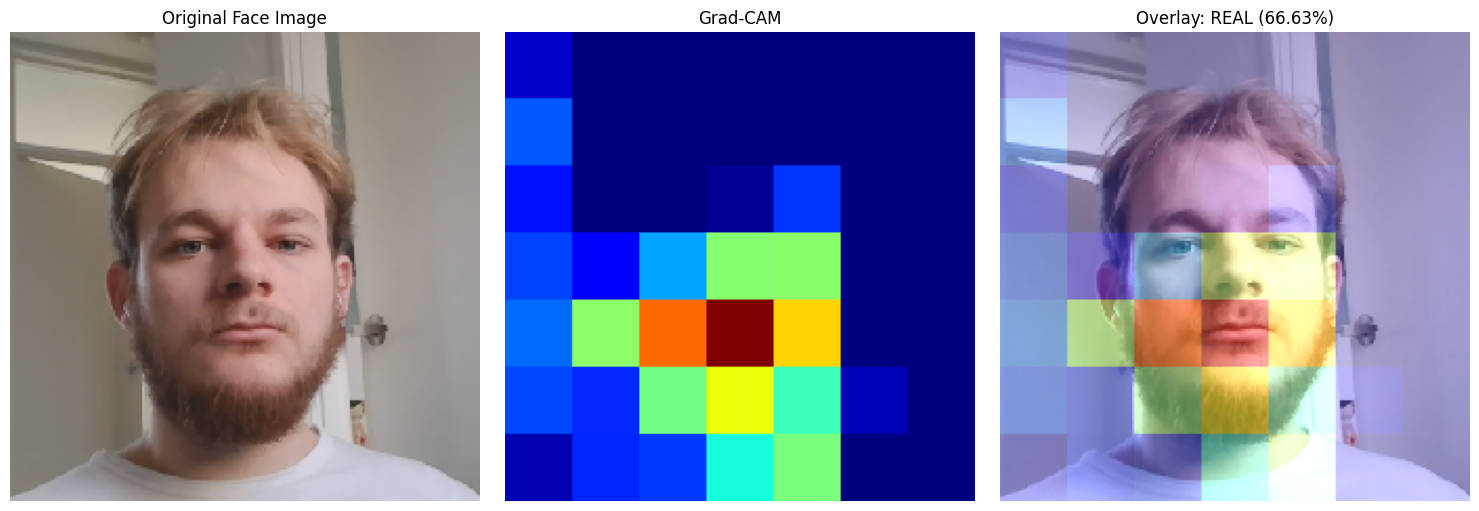

Image: frame_000225_20260515_153620_450682_face_1.jpg
Raw prediction: [[0.6663184  0.33368152]]
Detected as: real
Confidence: 66.63%


In [7]:
grad_model = build_gradcam_model(
    anti_spoof_model,
    layer_name="anti_spoof_conv"
)

label, confidence, pred, heatmap = predict_real_or_spoof_with_gradcam(
    latest_face_image,
    anti_spoof_model,
    grad_model,
    CLASS_NAMES
)